In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from tensorflow.keras.layers import LSTM, Dense, Dropout

**Reading dataset**

In [2]:
path = r'datasets/mega_dataset_scaled.csv'
df = pd.read_csv(path, parse_dates=['Date'])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind
0,2023-01-03,0.030398,0.435045,0.0,0.0,0.234763,0.273613,0.007028,2,0
1,2023-01-04,0.048458,0.435045,0.0,0.0,0.303612,0.261619,0.019661,2,1
2,2023-01-05,0.024341,0.435045,0.0,0.0,0.193002,0.224138,0.000000,2,-1
3,2023-01-06,0.060123,0.435045,0.0,0.0,0.302483,0.263868,0.038113,2,1
4,2023-01-09,0.064498,0.435045,0.0,0.0,0.460497,0.250375,0.036803,0,1


**Helper functions**

In [3]:
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i-seq_length:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)


In [12]:
def calculate_metrics(y_test, y_pred) -> None:
    """ 
        Function to evaluate the model that returns pandas.Dataframe object.
    """
    mse = mean_squared_error(y_pred, y_test)
    mae = mean_absolute_error(y_pred, y_test)
    r2 = r2_score(y_pred, y_test)

    res = pd.DataFrame({
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    })

    print(res)

In [7]:
features = [col for col in df.columns if col not in ['Date', 'Gold_Price']]
target = 'Gold_Price'

X = df[features]
y = df[target]

sequence_length = 60
X_seq, y_seq = create_sequences(X, y, sequence_length)


X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)


In [21]:
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(128, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))  
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model



In [22]:
model = build_lstm_model()
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)

TypeError: build_lstm_model() missing 1 required positional argument: 'input_shape'

In [10]:
y_pred = model.predict(X_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step


In [15]:
res = calculate_metrics(y_test, y_pred)
print(res)

ValueError: If using all scalar values, you must pass an index

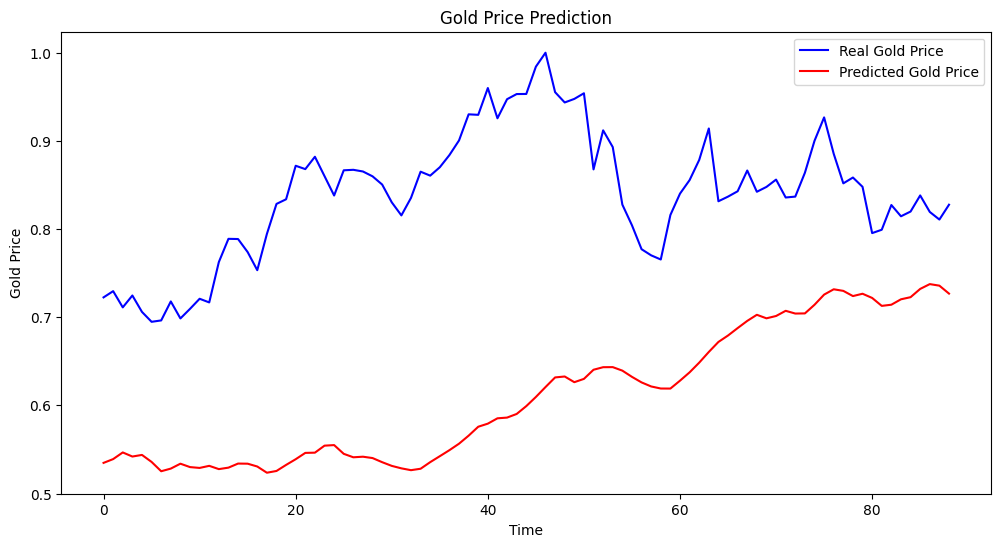

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, color='blue', label='Real Gold Price')
plt.plot(y_pred, color='red', label='Predicted Gold Price')
plt.title('Gold Price Prediction')
plt.xlabel('Time')
plt.ylabel('Gold Price')
plt.legend()
plt.show()


In [17]:
print("Final training loss:", history.history['loss'][-1])
print("Final validation loss:", history.history['val_loss'][-1])

Final training loss: 0.0014476190553978086
Final validation loss: 0.008380511775612831


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Assuming you already have these from predictions:
# y_test_rescaled, y_pred_rescaled

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.4f}')

RMSE: 0.25
MAE: 0.23
R² Score: -10.6853


**Increased dropout**

In [13]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.4))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(1))

c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [15]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0228 - val_loss: 0.0070
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0049 - val_loss: 0.0050
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0043 - val_loss: 0.0054
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0039 - val_loss: 0.0027
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0038 - val_loss: 0.0023
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0033 - val_loss: 0.0062
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0036 - val_loss: 0.0055
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0032 - val_loss: 0.0050
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0026 - val_loss: 0.0032
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0025 - val_loss: 0.0096
Epoch 12/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


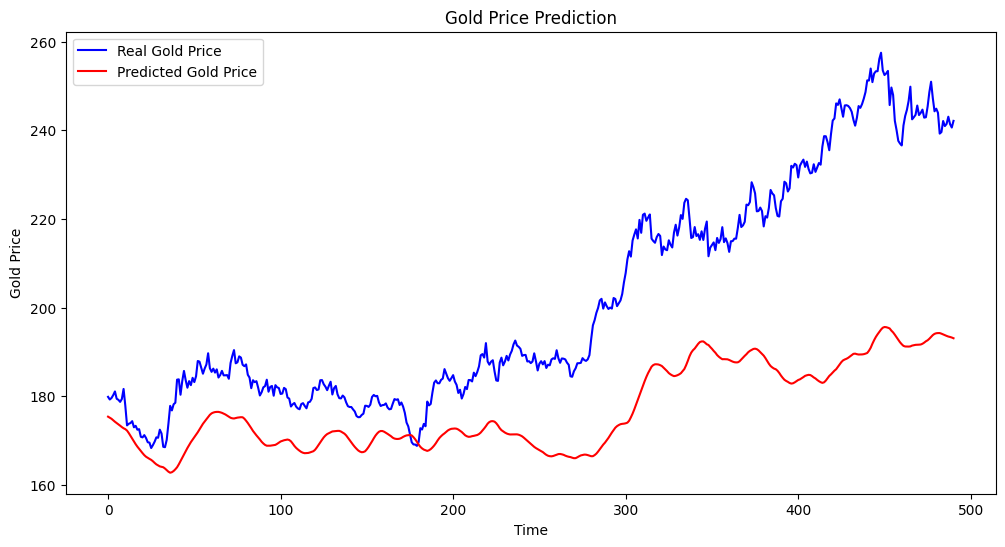

RMSE: 29.61
MAE: 24.28
R² Score: -0.3810


In [16]:
y_pred = model.predict(X_test)
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, color='blue', label='Real Gold Price')
plt.plot(y_pred_rescaled, color='red', label='Predicted Gold Price')
plt.title('Gold Price Prediction')
plt.xlabel('Time')
plt.ylabel('Gold Price')
plt.legend()
plt.show()

rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.4f}')

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

Epoch 1/50


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0167 - val_loss: 0.0021
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0041 - val_loss: 9.3681e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0017 - val_loss: 0.0012
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
RMSE: 15.48
MAE: 11.92
R² Score: 0.6245
Final training loss: 0.001614
Final validation loss: 0.001211


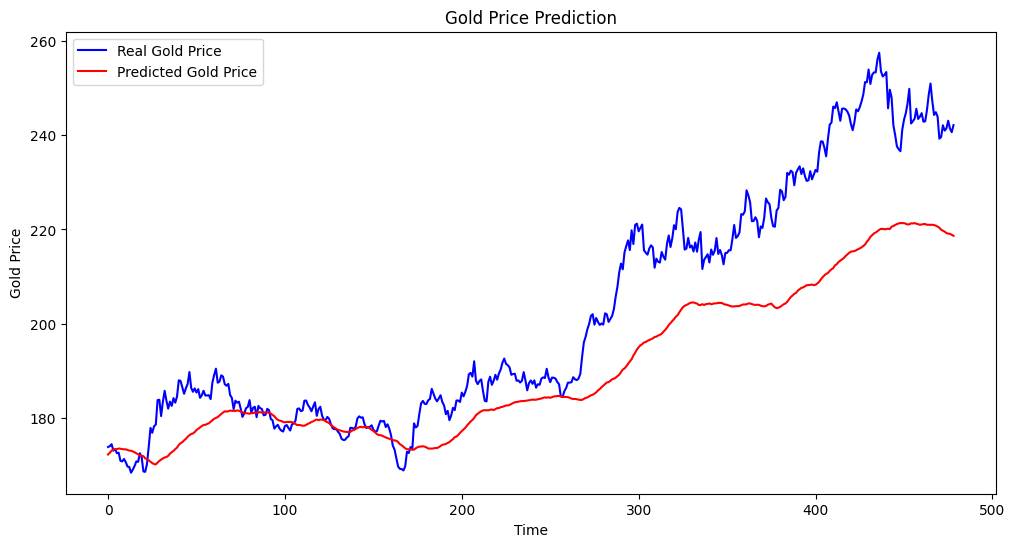

In [20]:
df = pd.read_csv(path)  # replace with your file path
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

df['SPX'] = df['^GSPC']
df['EUR/USD'] = df['EURUSD=X']
drop = ['^GSPC', 'EURUSD=X']
df = df.drop(columns=drop)

# Add optional moving average feature
df['GLD_MA_30'] = df['GLD'].rolling(window=30).mean()
df.dropna(inplace=True)  # drop rows with NaN due to rolling mean

# Features and target
features = ['SPX', 'USO', 'SLV', 'EUR/USD', 'GLD_MA_30']
target = 'GLD'

# Normalize
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_x.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

sequence_length = 90
X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)

split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Training with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_split=0.1, callbacks=[early_stop])

# Predict
y_pred = model.predict(X_test)
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.4f}')
print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Real Gold Price', color='blue')
plt.plot(y_pred_rescaled, label='Predicted Gold Price', color='red')
plt.title('Gold Price Prediction')
plt.xlabel('Time')
plt.ylabel('Gold Price')
plt.legend()
plt.show()

**Random Forest Regressor**

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2484 entries, 29 to 2512
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   GLD        2484 non-null   float64       
 1   USO        2484 non-null   float64       
 2   SLV        2484 non-null   float64       
 3   Date       2484 non-null   datetime64[ns]
 4   SPX        2484 non-null   float64       
 5   EUR/USD    2484 non-null   float64       
 6   GLD_MA_30  2484 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 155.2 KB


In [23]:
df = df.drop(columns=['GLD_MA_30'])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2484 entries, 29 to 2512
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   GLD      2484 non-null   float64       
 1   USO      2484 non-null   float64       
 2   SLV      2484 non-null   float64       
 3   Date     2484 non-null   datetime64[ns]
 4   SPX      2484 non-null   float64       
 5   EUR/USD  2484 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 135.8 KB


In [25]:
target = ['GLD']
features = [col for col in df.columns if col not in ['Date', target]]

scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

df.head()

,GLD,USO,SLV,Date,SPX,EUR/USD
29,0.111338,0.935795,0.259620,2015-02-13,0.062872,0.620405
30,0.098790,0.944890,0.225037,2015-02-17,0.063658,0.596407
31,0.100892,0.916533,0.221140,2015-02-18,0.063503,0.620673
32,0.098344,0.907972,0.218704,2015-02-19,0.062980,0.619067
33,0.094140,0.883895,0.210911,2015-02-20,0.065996,0.607637


In [26]:
X = df[features]

In [27]:
X

,GLD,USO,SLV,SPX,EUR/USD
29,0.111338,0.935795,0.259620,0.062872,0.620405
30,0.098790,0.944890,0.225037,0.063658,0.596407
31,0.100892,0.916533,0.221140,0.063503,0.620673
32,0.098344,0.907972,0.218704,0.062980,0.619067
33,0.094140,0.883895,0.210911,0.065996,0.607637
...,...,...,...,...,...
2508,0.897707,0.378612,0.770093,0.988212,0.277861
2509,0.908089,0.375134,0.775938,0.987637,0.275707
2510,0.897452,0.379949,0.757428,0.971973,0.283817
2511,0.892548,0.386437,0.741354,0.956977,0.285943


In [28]:
y = df[target]

In [29]:
y 

,GLD
29,0.111338
30,0.098790
31,0.100892
32,0.098344
33,0.094140
...,...
2508,0.897707
2509,0.908089
2510,0.897452
2511,0.892548


In [30]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [32]:
regressor = RandomForestRegressor(n_estimators=10, random_state=0, oob_score=True)

regressor.fit(X_train, y_train)

c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [33]:
y_pred = regressor.predict(X_test)

R² Score: 0.0099
Mean Squared Error: 0.0255


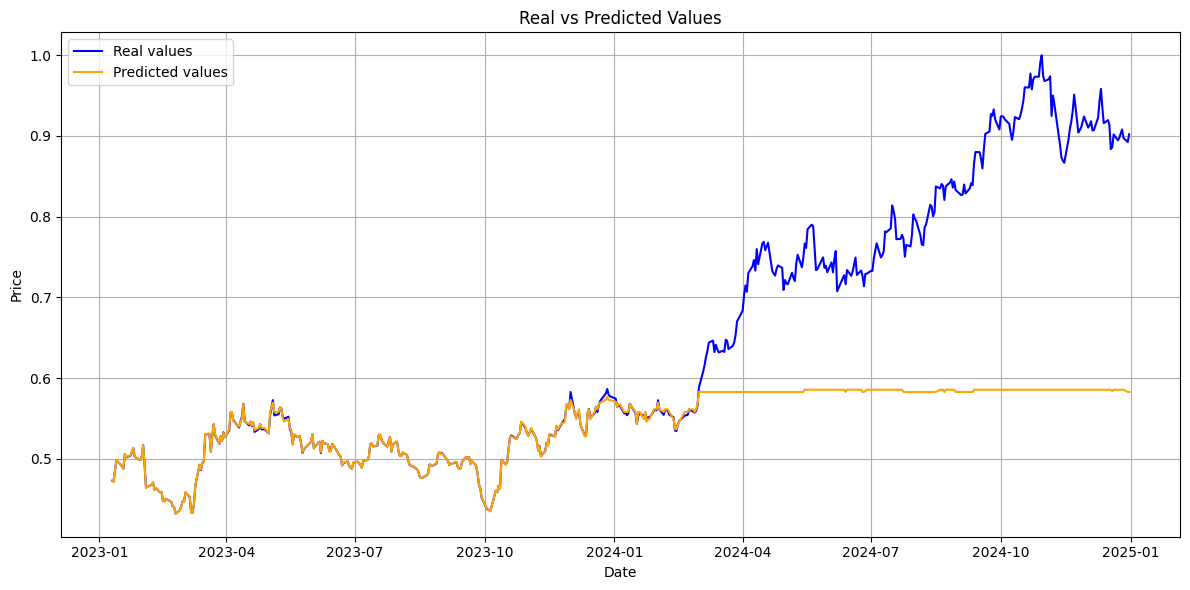

In [34]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

df['Date'] = pd.to_datetime(df['Date'])

date_test = df['Date'].iloc[split_index:]

plt.figure(figsize=(12, 6))
plt.plot(date_test, y_test, label='Real values', color='blue')
plt.plot(date_test, y_pred, label='Predicted values', color='orange')

plt.title('Real vs Predicted Values')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()